In [1729]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## 1. Contexto y carga del dataset

In [1730]:
#Carga Datset 1
df1 = pd.read_csv("../data/raw/diabetes.csv")
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


## 2. Exploración inicial de variables


In [1731]:
df1.describe()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


## 3. Evaluación de calidad de datos

In [1732]:
print(df1.isnull().sum())

id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64


In [1733]:
print(df1.duplicated().sum())

0


## 4. Limpieza y depuración de variables


In [1734]:
#Analisis de relacion para deducir sifnificado de bp.1s y bp.1d
print((df1["bp.1s"] > df1["bp.1d"]).mean())


0.9875930521091811


Al obtener un resultado muy cercano a 1 podemos asumir que s > d lo cual nos dice que estos valores corresponden a la presion arterial sistolica y distolica

In [1735]:
#Analisis estadístico de columnas de presión arterial
df1[["bp.1s", "bp.1d", "bp.2s", "bp.2d"]].describe().mean()


bp.1s    162.705694
bp.1d    114.238854
bp.2s    138.886991
bp.2d     88.135003
dtype: float64

El dataset incluye dos mediciones de presión arterial (sistólica y diastólica). 
Esto confirmado mediante su relacion y los rangos promedios que se calculan en el analisis descriptivo
siendo estos determinantes que: s > d (La presion sistolica es mayor que la distolica) y 
El promedio del rango de la presion sistolica ~90–180 y la presion distolica ~60–120
La decisión final de modelado se tomará tras evaluar su aporte predictivo.

In [1736]:
#Filtar valores no numéricos
bp_cols = ["bp.1s", "bp.1d", "bp.2s", "bp.2d"]
df1[bp_cols] = df1[bp_cols].apply(pd.to_numeric, errors="coerce")

In [1737]:
#Verificacion de nulos
df1[bp_cols].isnull().sum()

bp.1s      5
bp.1d      5
bp.2s    262
bp.2d    262
dtype: int64

In [1738]:
df1 = df1.drop(columns=["bp.2s", "bp.2d"])

In [1739]:
df1.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,44.0,41.0,300.0


Las variables correspondientes a la segunda toma de presión arterial (`bp.2s`, `bp.2d`)
presentan más del 65% de valores faltantes.  
Dado el tamaño reducido del dataset (~400 registros) y la imposibilidad de imputación
clínicamente justificada, estas variables fueron descartadas para evitar sesgos y pérdida
de estabilidad en los modelos predictivos.

## 5. Estandarización de unidades y coherencia clínica


In [1740]:
df1["height"] = df1["height"] * 0.0254
df1["weight"] = df1["weight"] * 0.453592

In [1741]:
#Verificacion estadistica del calulo de las nuevas variables
df1[["height", "weight",]].describe()


,height,weight
count,398.000000,402.000000
mean,1.676911,80.554329
std,0.099530,18.298203
min,1.320800,44.905608
25%,1.600200,68.492392
50%,1.676400,78.244620
75%,1.752600,90.718400
max,1.930400,147.417400


In [1742]:
df1 = df1.drop(columns=["id", "waist", "hip","location", "frame"])

In [1743]:
df1.head()

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,bp.1s,bp.1d,time.ppn
0,203.0,82,56.0,3.6,4.31,46,female,1.5748,54.884632,118.0,59.0,720.0
1,165.0,97,24.0,6.9,4.44,29,female,1.6256,98.883056,112.0,68.0,360.0
2,228.0,92,37.0,6.2,4.64,58,female,1.5494,116.119552,190.0,92.0,180.0
3,78.0,93,12.0,6.5,4.63,67,male,1.7018,53.977448,110.0,50.0,480.0
4,249.0,90,28.0,8.9,7.72,64,male,1.7272,83.007336,138.0,80.0,300.0


Las variables antropométricas originales se encontraban en unidades imperiales
(pulgadas y libras). Se realizó la conversión a unidades métricas (metros y kilogramos)
para garantizar consistencia y permitir el cálculo del Índice de Masa Corporal (BMI).
El BMI fue incorporado como variable derivada clínicamente estandarizada.
Y realizo la eliminacion de variables no relevantes para el estudio.

## 6. Creación de variables derivadas


In [1744]:
#Calculo de IMC(BMI)
df1["bmi"] = df1["weight"] / (df1["height"] ** 2)

In [1745]:
df1["bmi"].describe()

count    397.000000
mean      28.787396
std        6.606538
min       15.204780
25%       24.128995
50%       27.802690
75%       32.239496
max       55.785505
Name: bmi, dtype: float64

In [1746]:
#calculo de la variable objetivo a partir de la hemoglobina A1c (Segun lo documentado en el dataset)
df1["target"] = (df1["glyhb"] >= 6.5).astype(int)

In [1747]:
df1["target"].value_counts()

target
0    338
1     65
Name: count, dtype: int64

La variable objetivo original es continua.
Siguiendo el criterio clínico del dataset, se binarizó considerando valores ≥ 6.5 como presencia de la enfermedad (1) y valores < 6.5 como ausencia (0).
Esta transformación permite aplicar modelos de clasificación supervisada.

In [1748]:
df1.head()

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,bp.1s,bp.1d,time.ppn,bmi,target
0,203.0,82,56.0,3.6,4.31,46,female,1.5748,54.884632,118.0,59.0,720.0,22.130944,0
1,165.0,97,24.0,6.9,4.44,29,female,1.6256,98.883056,112.0,68.0,360.0,37.419200,0
2,228.0,92,37.0,6.2,4.64,58,female,1.5494,116.119552,190.0,92.0,180.0,48.370241,0
3,78.0,93,12.0,6.5,4.63,67,male,1.7018,53.977448,110.0,50.0,480.0,18.637828,0
4,249.0,90,28.0,8.9,7.72,64,male,1.7272,83.007336,138.0,80.0,300.0,27.824747,1


## 7. Codificación de variables categóricas


In [1749]:
#codificacion de genero
df1["gender_encoded"] = df1["gender"].map({
    "male": 1,
    "female": 0
})

In [1750]:
df1["gender_encoded"].value_counts()


gender_encoded
0    234
1    169
Name: count, dtype: int64

La variable categórica `gender` fue codificada de forma binaria
(0 = femenino, 1 = masculino) para permitir su inclusión
en el análisis de correlación y modelos de clasificación.

## 8. Escalado y normalización de variables numéricas


In [1751]:
#analisis de correlacion entre variables numericas
num_cols_scaled = [
    "age",
    "chol",
    "hdl",
    "ratio",
    "glyhb",
    "stab.glu",
    "bp.1s",
    "bp.1d",
    "height",
    "weight",
    "bmi",
    "time.ppn"
]
num_cols_corr = num_cols_scaled + ["gender_encoded"]

In [1752]:
scaler = StandardScaler()
df_scaled = df1.copy()
df_scaled[num_cols_scaled] = scaler.fit_transform(df1[num_cols_scaled])

In [1753]:
df_scaled[num_cols_scaled].describe()

,age,chol,hdl,ratio,glyhb,stab.glu,bp.1s,bp.1d,height,weight,bmi,time.ppn
count,4.030000e+02,4.020000e+02,4.020000e+02,4.020000e+02,3.900000e+02,4.030000e+02,3.980000e+02,3.980000e+02,3.980000e+02,4.020000e+02,3.970000e+02,400.000000
mean,-1.498663e-16,-1.833801e-16,-1.502391e-16,-1.855895e-16,-1.958547e-16,1.410507e-16,7.810614e-17,4.195416e-16,1.856695e-15,-3.888542e-16,-2.818904e-16,0.000000
std,1.001243e+00,1.001246e+00,1.001246e+00,1.001246e+00,1.001285e+00,1.001243e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001246e+00,1.001262e+00,1.001252
min,-1.709488e+00,-2.925097e+00,-2.229857e+00,-1.750930e+00,-1.299168e+00,-1.106803e+00,-2.065146e+00,-2.602508e+00,-3.582415e+00,-1.950636e+00,-2.058530e+00,-1.087646
25%,-7.887952e-01,-6.498223e-01,-7.218358e-01,-7.658425e-01,-5.401435e-01,-4.842876e-01,-6.892486e-01,-6.131388e-01,-7.716959e-01,-6.600084e-01,-7.060094e-01,-0.812702
50%,-1.136206e-01,-8.663551e-02,-2.578294e-01,-1.863796e-01,-3.347605e-01,-3.333749e-01,-3.982498e-02,-9.737651e-02,-5.136079e-03,-1.263833e-01,-1.492382e-01,-0.327507
75%,8.070720e-01,4.990788e-01,4.961810e-01,5.089762e-01,4.567838e-03,-1.268528e-02,4.334838e-01,4.920661e-01,7.614237e-01,5.561605e-01,5.231872e-01,0.570105
max,2.771216e+00,5.297431e+00,4.034230e+00,8.563512e+00,4.697123e+00,5.250397e+00,4.979449e+00,2.997197e+00,2.550063e+00,3.658632e+00,4.091731e+00,3.942213


Las variables numéricas fueron estandarizadas mediante StandardScaler,
obteniendo una media cercana a cero y desviación estándar unitaria.
La aparición de valores en notación científica responde a la precisión
numérica de punto flotante y no representa una distorsión de los datos.

## 9. Análisis de correlación


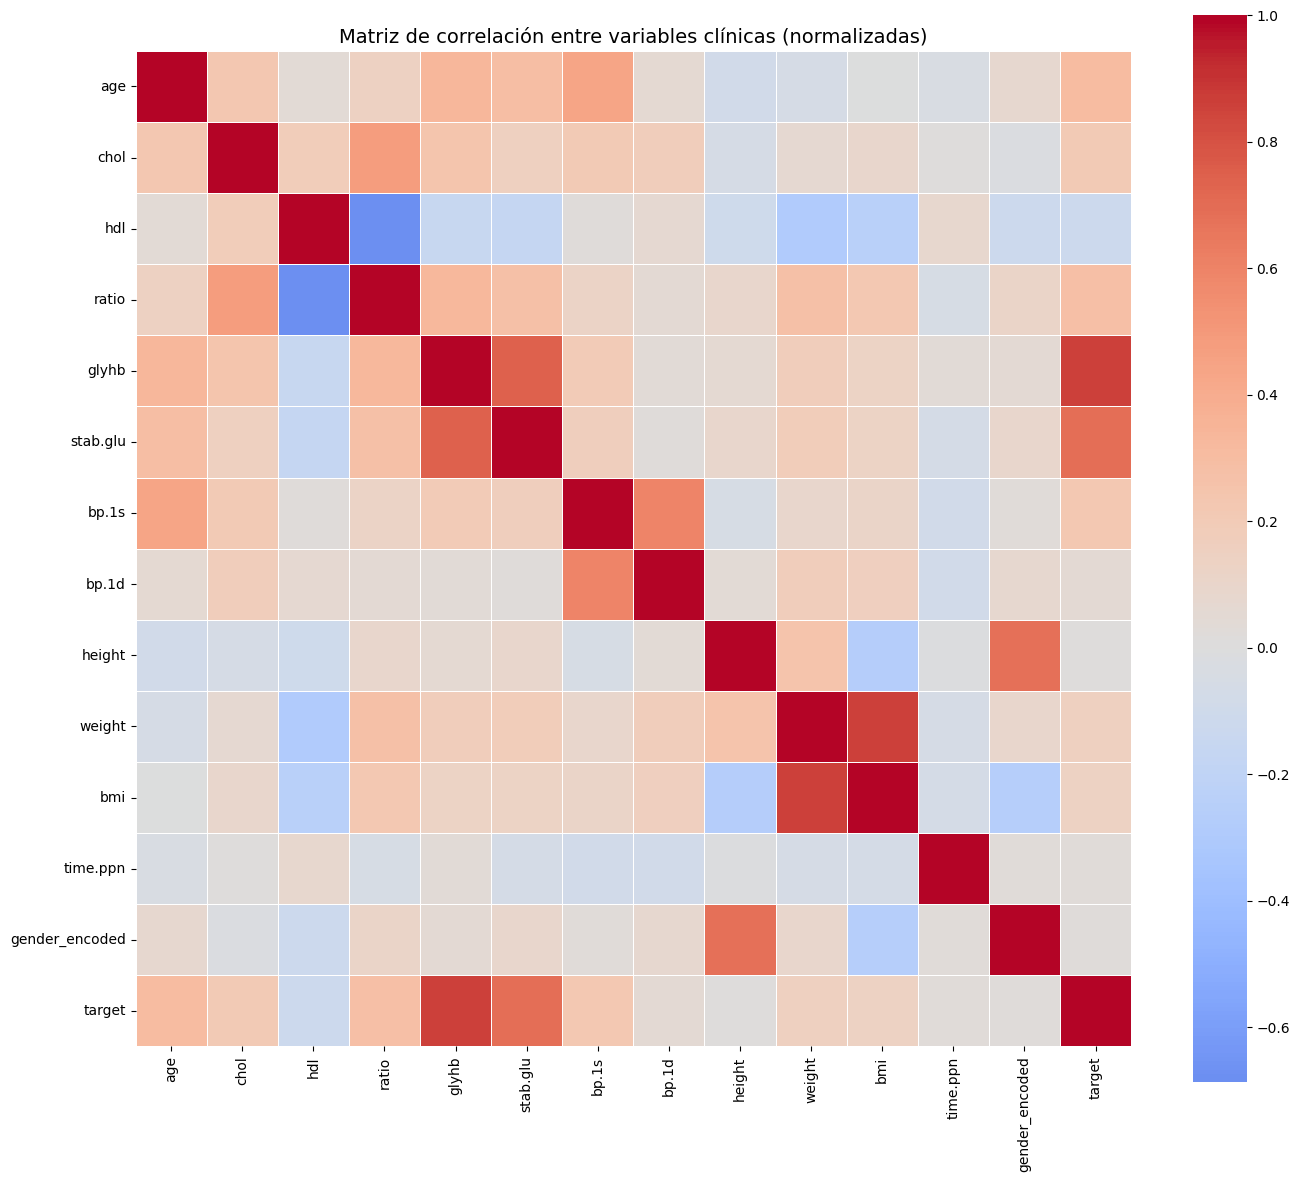

In [1754]:
# Variables a incluir en la correlación
corr_cols = num_cols_corr + ["target"]

# Cálculo de la matriz de correlación
corr_matrix = df_scaled[corr_cols].corr()

# Visualización
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables clínicas (normalizadas)", fontsize=14)
plt.tight_layout()
plt.show()

Se empleó una matriz de correlación sobre variables numéricas
previamente estandarizadas, con el fin de analizar relaciones lineales
y detectar posibles problemas de colinealidad antes del entrenamiento
de los modelos de clasificación.

## 10. Observaciones preliminares del EDA


Despues de realizar el analisis de las variables presentes en este dataset se decide conservar las siguientes columnas:
"Age", "gender_encoded", "glyhb"(HbA1c)-hemoglobina glicosilada, "stab.glu" (Glucosa en sangre), "bmi" ya que son variables facilmente medibles y con altos niveles de correlacion con la variable objetivo

## 1. Contexto y carga del dataset

In [1755]:
#Carga Datset 2
df2 = pd.read_csv("../data/raw/diabetes_prediction_dataset.csv")
df2.info()
df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Exploración inicial de variables

In [1756]:
df2.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## 3. Evaluación de calidad de datos

In [1757]:
print(df2.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [1758]:
print(df2.duplicated().sum())

3854


## 4. Limpieza y depuración de variables


Al darnos cuenta de que hay un gan volumen de datos duplicados decidimos eliminarlos por completo para evitar la redundacia de datos

In [1759]:
df2=df2.drop_duplicates()

In [1760]:
df2["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [1761]:
df2["gender"].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Cuando se obsevan los datos unicos del campo genero observamos una categoria "other" la cual no se considera relevante para estudiar la correlacion del genero con la adquision de la diabetes por lo cual se toma la decision de eliminar los registros con esta caracteristica

In [1762]:
df2=df2[df2["gender"]!="Other"]

In [1763]:
df2["gender"].value_counts()

gender
Female    56161
Male      39967
Name: count, dtype: int64

In [1764]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96128 non-null  object 
 1   age                  96128 non-null  float64
 2   hypertension         96128 non-null  int64  
 3   heart_disease        96128 non-null  int64  
 4   smoking_history      96128 non-null  object 
 5   bmi                  96128 non-null  float64
 6   HbA1c_level          96128 non-null  float64
 7   blood_glucose_level  96128 non-null  int64  
 8   diabetes             96128 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [1765]:
df2["smoking_history"].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [1766]:
df2["smoking_history"].value_counts()

smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64

## 5. Estandarización de unidades y coherencia clínica

In [1767]:
df2["bmi"].describe()

count    96128.000000
mean        27.321450
std          6.767811
min         10.010000
25%         23.400000
50%         27.320000
75%         29.860000
max         95.690000
Name: bmi, dtype: float64

In [1768]:
df2["blood_glucose_level"].describe()

count    96128.000000
mean       138.218001
std         40.911190
min         80.000000
25%        100.000000
50%        140.000000
75%        159.000000
max        300.000000
Name: blood_glucose_level, dtype: float64

In [1769]:
df2["HbA1c_level"].describe()

count    96128.000000
mean         5.532633
std          1.073225
min          3.500000
25%          4.800000
50%          5.800000
75%          6.200000
max          9.000000
Name: HbA1c_level, dtype: float64

Las variables numericas cumplen con el estandar de unidades y por ende no hay que realizar ninguna conversion para los calculos futuros

## 6. Creación de variables derivadas

En este caso no hay variables que se puedan crear a partir de las ya existentes, sin embargo las variables se pueden codificar para seguir adelante con la matriz de correlacion

## 7. Codificación de variables categóricas


Analizando el contenido de este dataset tenemos un gran volumen de informacion y variables muy similares a las del dataset anterior, por ende se realiza el calculo de las variables codificadas

In [1770]:
#Codificacion de genero
df2["gender_encoded"] = df2["gender"].map({
    "Male": 1,
    "Female": 0
})


In [1771]:
df2["gender_encoded"].value_counts()  

gender_encoded
0    56161
1    39967
Name: count, dtype: int64

La variable genero se codifico de la manera Male=1 Female=0 para el posterior entrenamiento de los modelos

In [1772]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96128 non-null  object 
 1   age                  96128 non-null  float64
 2   hypertension         96128 non-null  int64  
 3   heart_disease        96128 non-null  int64  
 4   smoking_history      96128 non-null  object 
 5   bmi                  96128 non-null  float64
 6   HbA1c_level          96128 non-null  float64
 7   blood_glucose_level  96128 non-null  int64  
 8   diabetes             96128 non-null  int64  
 9   gender_encoded       96128 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 8.1+ MB


In [1773]:
df2 = df2.rename(columns={"diabetes": "target",
    "HbA1c_level": "HbA1c",
    "blood_glucose_level": "blood_glucose"})


In [1774]:
df2_Smoking_history = pd.get_dummies(df2, columns=["smoking_history"], drop_first=False)


In [1775]:
df2["smoking_history_encoded"] = df2["smoking_history"].map({ "No Info": 0, "never": 1, "former": 2, "ever": 3, "not current": 4, "current": 5 })

In [1776]:
df2.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c,blood_glucose,target,gender_encoded,smoking_history_encoded
0,Female,80.0,0,1,never,25.19,6.6,140,0,0,1
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,0,0
2,Male,28.0,0,0,never,27.32,5.7,158,0,1,1
3,Female,36.0,0,0,current,23.45,5.0,155,0,0,5
4,Male,76.0,1,1,current,20.14,4.8,155,0,1,5


In [1777]:
df2_Smoking_history.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c,blood_glucose,target,gender_encoded,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,Female,80.0,0,1,25.19,6.6,140,0,0,False,False,False,False,True,False
1,Female,54.0,0,0,27.32,6.6,80,0,0,True,False,False,False,False,False
2,Male,28.0,0,0,27.32,5.7,158,0,1,False,False,False,False,True,False
3,Female,36.0,0,0,23.45,5.0,155,0,0,False,True,False,False,False,False
4,Male,76.0,1,1,20.14,4.8,155,0,1,False,True,False,False,False,False


Se realiza la distincion de 2 data frames diferentes, uno con el historial de tabaquismo codificado por one-hot y uno con codificacion manual, para comparar la relevancia y resultados de los modelos a entrenar al realizar esta distincion 

## 8. Escalado y normalización de variables numéricas


In [1778]:
#analisis de correlacion entre variables numericas y codificacion manual de smoking history
num_cols_scaled = [
    "age",
    "bmi",
    "blood_glucose",
    "HbA1c"
]
num_cols_corr = num_cols_scaled + ["gender_encoded"] + ["hypertension"] + [ "heart_disease"] + ["smoking_history_encoded"]

In [1779]:
scaler = StandardScaler()
df_scaled = df2.copy()
df_scaled[num_cols_scaled] = scaler.fit_transform(df2[num_cols_scaled])

In [1780]:
df_scaled[num_cols_scaled].describe()

,age,bmi,blood_glucose,HbA1c
count,9.612800e+04,9.612800e+04,9.612800e+04,9.612800e+04
mean,7.687297e-18,-3.840692e-16,3.193185e-16,1.002453e-15
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-1.857108e+00,-2.557923e+00,-1.423041e+00,-1.893958e+00
25%,-7.922561e-01,-5.794297e-01,-9.341747e-01,-6.826495e-01
50%,5.357126e-02,-2.142881e-04,4.355797e-02,2.491266e-01
75%,7.658470e-01,3.750937e-01,5.079810e-01,6.218370e-01
max,1.700709e+00,1.010207e+01,3.954489e+00,3.230810e+00


In [1781]:
df2_Smoking_history.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       96128 non-null  object 
 1   age                          96128 non-null  float64
 2   hypertension                 96128 non-null  int64  
 3   heart_disease                96128 non-null  int64  
 4   bmi                          96128 non-null  float64
 5   HbA1c                        96128 non-null  float64
 6   blood_glucose                96128 non-null  int64  
 7   target                       96128 non-null  int64  
 8   gender_encoded               96128 non-null  int64  
 9   smoking_history_No Info      96128 non-null  bool   
 10  smoking_history_current      96128 non-null  bool   
 11  smoking_history_ever         96128 non-null  bool   
 12  smoking_history_former       96128 non-null  bool   
 13  smoking_history_never

In [1782]:
#analisis de correlacion entre variables numericas y codificacion hot de smoking history
num_cols_scaled = [
    "age",
    "bmi",
    "blood_glucose",
    "HbA1c"
]
num_cols_corr_2 = num_cols_scaled + ["gender_encoded"] + ["hypertension"] + [ "heart_disease"] + ["smoking_history_ever", "smoking_history_former", "smoking_history_not current", "smoking_history_current", "smoking_history_never", "smoking_history_No Info" ]

In [1783]:
scaler = StandardScaler()
df_scaled_2 = df2_Smoking_history.copy()
df_scaled_2[num_cols_scaled] = scaler.fit_transform(df2_Smoking_history[num_cols_scaled])

Las variables numéricas fueron estandarizadas mediante StandardScaler,
obteniendo una media cercana a cero y desviación estándar unitaria.
La aparición de valores en notación científica responde a la precisión
numérica de punto flotante y no representa una distorsión de los datos.

## 9. Análisis de correlación

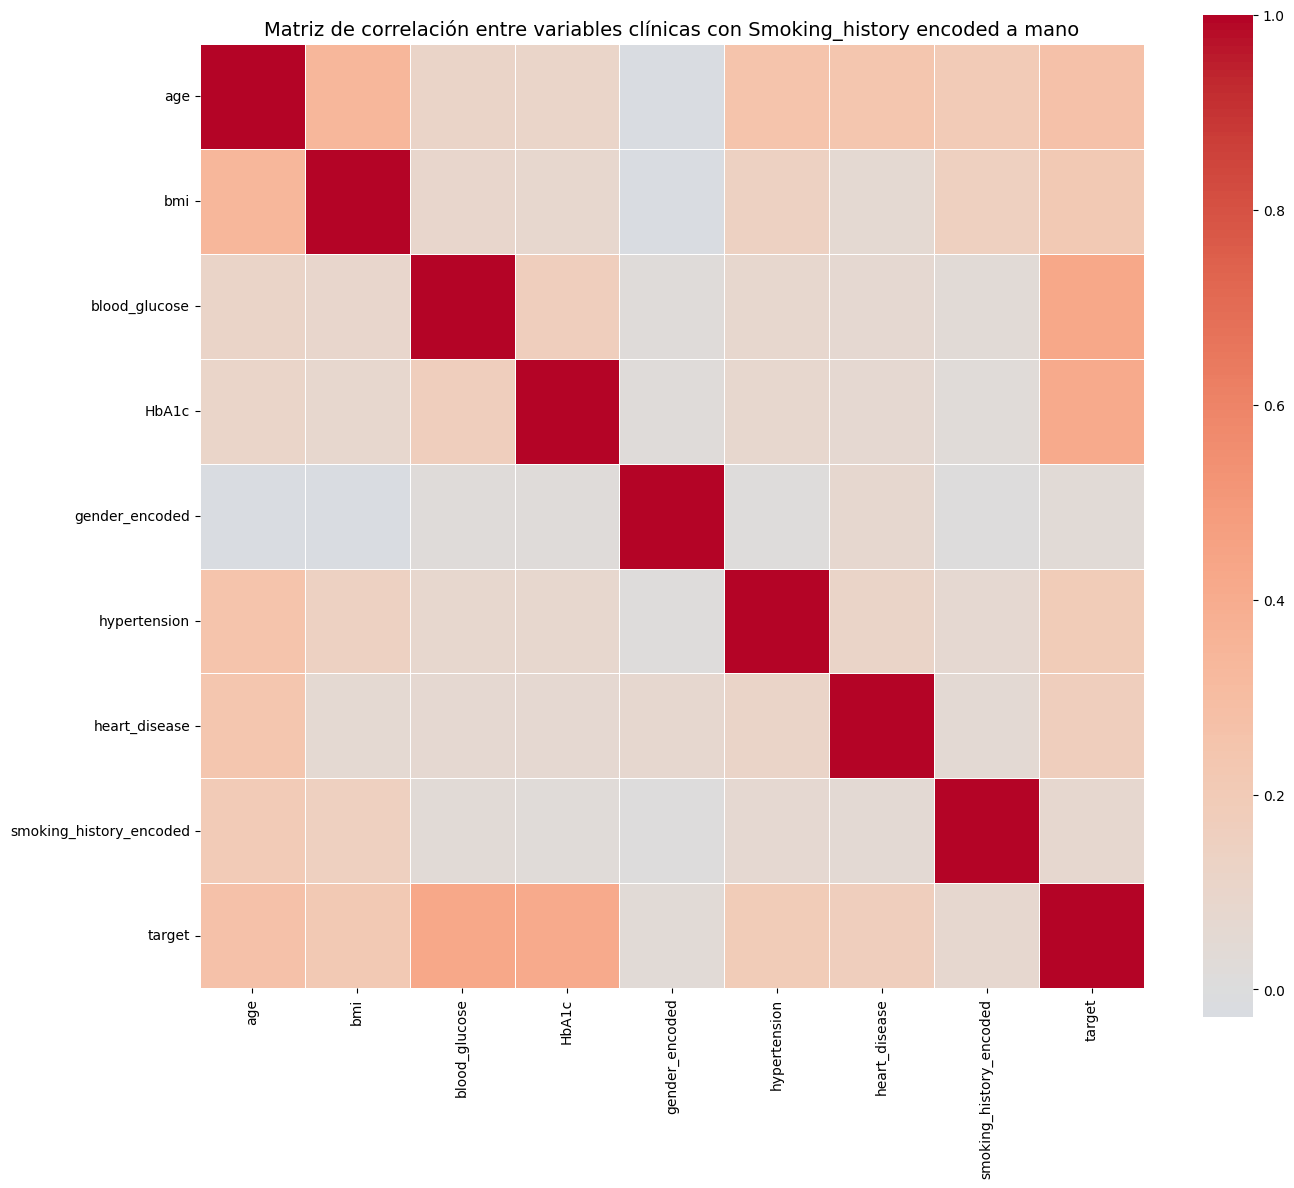

In [1784]:
# Variables a incluir en la correlación
corr_cols = num_cols_corr + ["target"]

# Cálculo de la matriz de correlación
corr_matrix = df_scaled[corr_cols].corr()

# Visualización
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables clínicas con Smoking_history encoded a mano", fontsize=14)
plt.tight_layout()
plt.show()

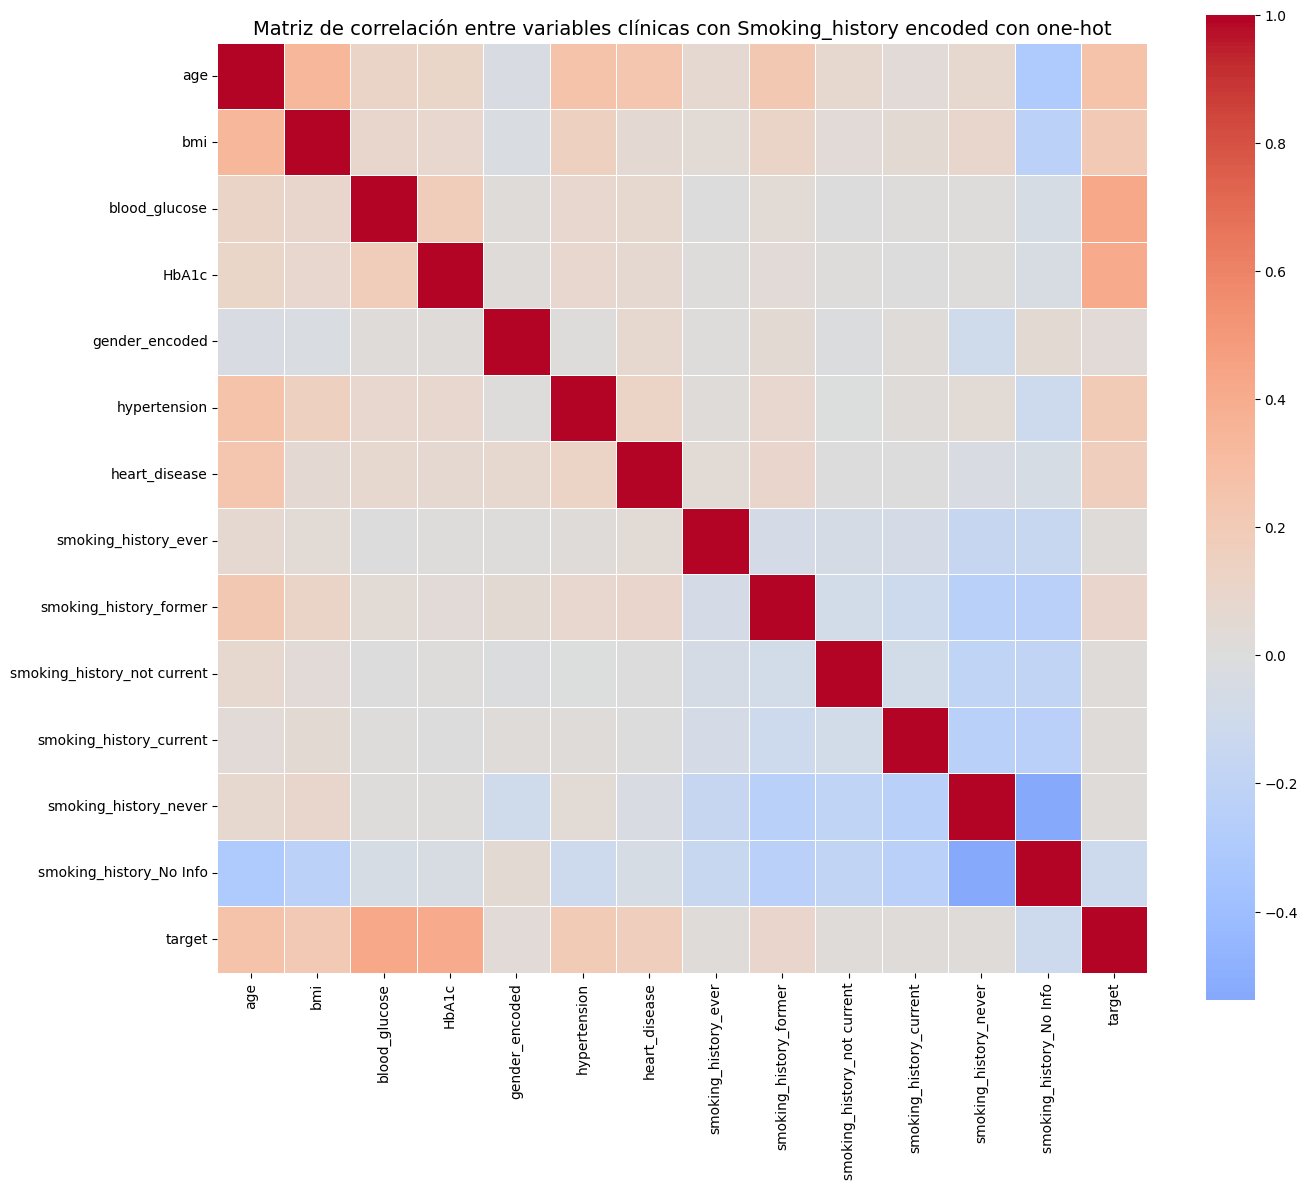

In [1785]:
# Variables a incluir en la correlación
corr_cols_2 = num_cols_corr_2 + ["target"]

# Cálculo de la matriz de correlación
corr_matrix = df_scaled_2[corr_cols_2].corr()

# Visualización
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables clínicas con Smoking_history encoded con one-hot", fontsize=14)
plt.tight_layout()
plt.show()

Se empleó una matriz de correlación sobre variables numéricas
previamente estandarizadas, con el fin de analizar relaciones lineales
y detectar posibles problemas de colinealidad antes del entrenamiento
de los modelos de clasificación.

## 10. Observaciones preliminares del EDA


Despues de realizar el analisis de las variables presentes en este dataset se decide:
"Age", "gender_encoded", "HbA1c"-hemoglobina glicosilada, "blood_glucose" (Glucosa en sangre), "bmi" son variables que tambien se presentan en el primer dataset analizado, e igualmente son faciles de medir y sus niveles de correlacion con la variable objetivo son suficientes para considerarlas para el entrenamiento del modelo de machine learning, sin embargo, se decide escoger las variables  "Hypertension" y "heart_disease" para añadir variables de valor para el ajuste del riesgo y usando HbA1c y la glucosa en sangre como los determinates principales para la prediccion 

In [1786]:
df2.drop(columns=["smoking_history", "gender"], inplace=True)
df2_Smoking_history.drop(columns=["gender"], inplace=True)

In [1787]:
df2.to_csv("../data/processed/diabetes_prediction.csv", index=False)
df2_Smoking_history.to_csv("../data/processed/diabetes_prediction_smoking_history_encoded.csv", index=False)